In [4]:
print("Step 1: Importing Libraries...")

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Libraries imported successfully!\n")

Step 1: Importing Libraries...
Libraries imported successfully!



In [5]:
print("Step 2: Loading Dataset...")

df = pd.read_csv("/content/iphone_purchase_records.csv")

print("Dataset Shape:", df.shape)
print(df.head())

Step 2: Loading Dataset...
Dataset Shape: (400, 4)
   Gender  Age  Salary  Purchase Iphone
0    Male   19   19000                0
1    Male   35   20000                0
2  Female   26   43000                0
3  Female   27   57000                0
4    Male   19   76000                0


In [6]:
print("\nStep 3: Data Understanding")

print("\nMissing Values:\n", df.isnull().sum())
print("\nData Types:\n", df.dtypes)
print("\nStatistical Summary:\n", df.describe().round(2))


Step 3: Data Understanding

Missing Values:
 Gender             0
Age                0
Salary             0
Purchase Iphone    0
dtype: int64

Data Types:
 Gender             object
Age                 int64
Salary              int64
Purchase Iphone     int64
dtype: object

Statistical Summary:
           Age     Salary  Purchase Iphone
count  400.00     400.00           400.00
mean    37.66   69742.50             0.36
std     10.48   34096.96             0.48
min     18.00   15000.00             0.00
25%     29.75   43000.00             0.00
50%     37.00   70000.00             0.00
75%     46.00   88000.00             1.00
max     60.00  150000.00             1.00



Step 4: Performing EDA...


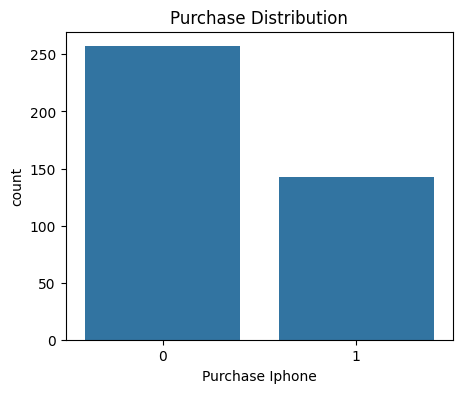

Insight: More users did NOT purchase iPhone (class imbalance).


In [8]:
print("\nStep 4: Performing EDA...")

plt.figure(figsize=(5,4))
sns.countplot(x='Purchase Iphone', data=df)
plt.title("Purchase Distribution")
plt.show()
print("Insight: More users did NOT purchase iPhone (class imbalance).")

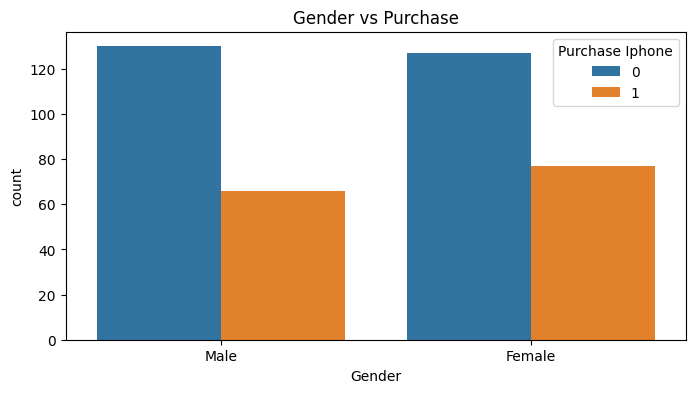

Insight: Gender has minimal impact on purchase decision.


In [10]:
plt.figure(figsize=(8,4))
sns.countplot(x='Gender', hue='Purchase Iphone', data=df)
plt.title("Gender vs Purchase")
plt.show()

print("Insight: Gender has minimal impact on purchase decision.")

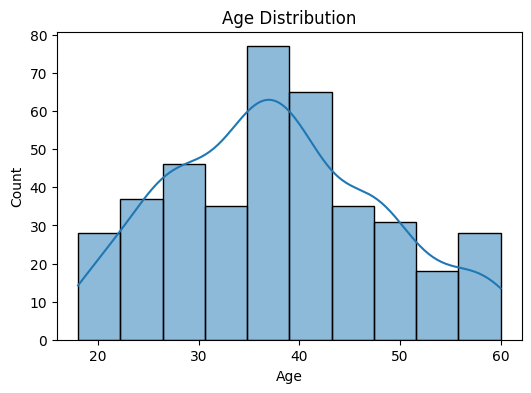

Insight: Majority users are between age 20–40.


In [11]:
plt.figure(figsize=(6,4))
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")
plt.show()

print("Insight: Majority users are between age 20–40.")

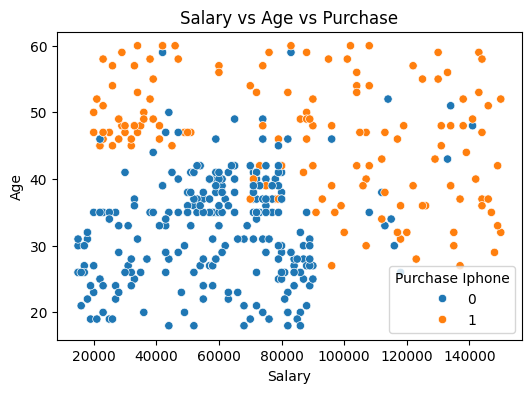

Insight: High salary + higher age → more chances of purchase.


In [12]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='Salary', y='Age', hue='Purchase Iphone', data=df)
plt.title("Salary vs Age vs Purchase")
plt.show()

print("Insight: High salary + higher age → more chances of purchase.")

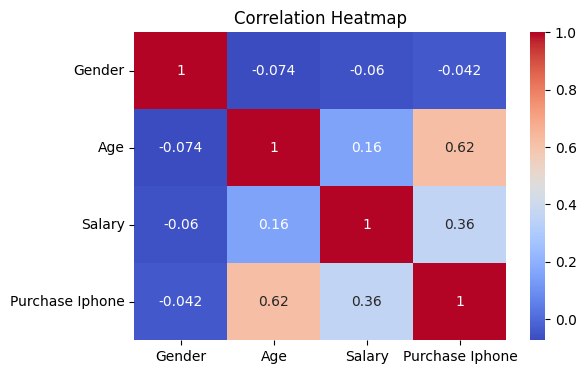

Insight: Age & Salary strongly influence purchase.


In [14]:
# Encode temporarily for heatmap
df_temp = df.copy()
df_temp['Gender'] = LabelEncoder().fit_transform(df_temp['Gender'])

plt.figure(figsize=(6,4))
sns.heatmap(df_temp.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

print("Insight: Age & Salary strongly influence purchase.")

In [15]:
print("Step 6: Preprocessing Data...")

le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

X = df[['Gender', 'Age', 'Salary']]
y = df['Purchase Iphone']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Preprocessing Completed!\n")

Step 6: Preprocessing Data...
Preprocessing Completed!



In [16]:
print("Step 7: Splitting Data...")

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Step 7: Splitting Data...
Train Shape: (320, 3)
Test Shape: (80, 3)


In [17]:
print("\nStep 8: Training Decision Tree Model...")

model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train, y_train)

print("Model trained successfully!")


Step 8: Training Decision Tree Model...
Model trained successfully!


In [18]:
print("\nStep 9: Making Predictions...")

y_pred = model.predict(X_test)

print("Sample Predictions:", y_pred[:10])


Step 9: Making Predictions...
Sample Predictions: [1 1 0 1 0 0 1 0 0 0]


In [19]:
print("\nStep 10: Evaluating Model...")

accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", round(accuracy, 3))
print("\nConfusion Matrix:\n", cm)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Step 10: Evaluating Model...
Accuracy: 0.912

Confusion Matrix:
 [[48  4]
 [ 3 25]]

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.92      0.93        52
           1       0.86      0.89      0.88        28

    accuracy                           0.91        80
   macro avg       0.90      0.91      0.90        80
weighted avg       0.91      0.91      0.91        80



In [20]:
print("\nStep 11: Cross Validation...")

cv_scores = cross_val_score(model, X_scaled, y, cv=5)

print("CV Scores:", np.round(cv_scores, 3))
print("Mean CV Score:", round(cv_scores.mean(), 3))


Step 11: Cross Validation...
CV Scores: [0.8   0.938 0.85  0.762 0.788]
Mean CV Score: 0.827


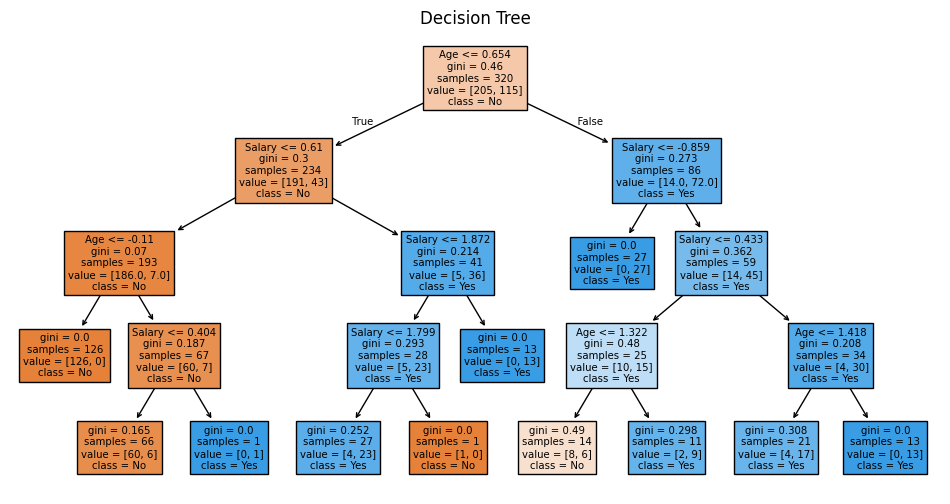

In [21]:
plt.figure(figsize=(12,6))
plot_tree(model, feature_names=['Gender','Age','Salary'],
          class_names=['No','Yes'], filled=True)

plt.title("Decision Tree")
plt.show()

In [22]:
print("\nFeature Importance:")

importance = model.feature_importances_

for i, col in enumerate(['Gender','Age','Salary']):
    print(f"{col}: {round(importance[i],3)}")


Feature Importance:
Gender: 0.0
Age: 0.505
Salary: 0.495


In [23]:
print("""
Final Inference:

1. Salary and Age are the most important factors.
2. Customers with higher salary are more likely to purchase.
3. Age group above 35 shows higher conversion.
4. Gender has minimal influence.
5. Decision Tree performs well with good accuracy.
6. Model can be used for targeted marketing campaigns.
""")


Final Inference:

1. Salary and Age are the most important factors.
2. Customers with higher salary are more likely to purchase.
3. Age group above 35 shows higher conversion.
4. Gender has minimal influence.
5. Decision Tree performs well with good accuracy.
6. Model can be used for targeted marketing campaigns.

